C:\Users\benol\AppData\Local\Temp\ipykernel_23488\3946097567.py:8: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mean_img = image.mean_img(subject_1)


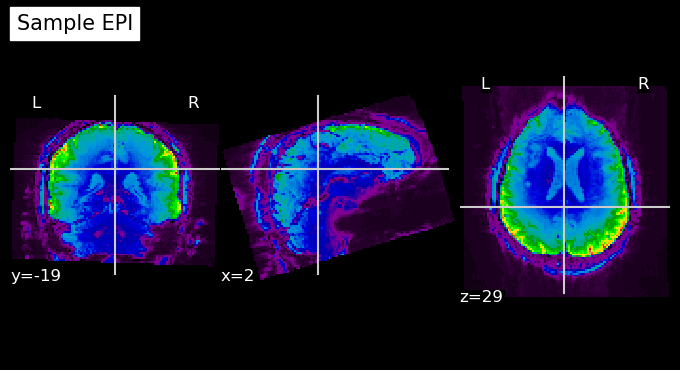

In [3]:
from nilearn import image
import nilearn.plotting as plotting
import os


data_dir = os.path.join('E:\\', 'neuro_data', 'ds004796')
subject_1 = os.path.join(data_dir, 'sub-01', 'func','sub-01_task-rest_dir-PA_bold.nii.gz')
mean_img = image.mean_img(subject_1)
plotting.plot_epi(mean_img, title="Sample EPI")

In [11]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display


img = nib.load(subject_1)
data = img.get_fdata()

# Choose which slice to view (e.g., middle axial)
z_slice = data.shape[2] // 2
slice_data = data[:, :, z_slice, :]  # shape: (x, y, time)
slice_data = (slice_data - np.min(slice_data)) / (np.max(slice_data) - np.min(slice_data))


# Set up interactive widget
@widgets.interact(t=widgets.IntSlider(min=0, max=slice_data.shape[-1]-1, step=1, value=0))
def update(t=0):
    plt.figure(figsize=(5, 5))
    plt.imshow(slice_data[:, :, t], cmap='gray', origin='lower')
    plt.title(f"Timepoint: {t}")
    plt.axis('off')
    plt.show()

interactive(children=(IntSlider(value=0, description='t', max=559), Output()), _dom_classes=('widget-interact'…

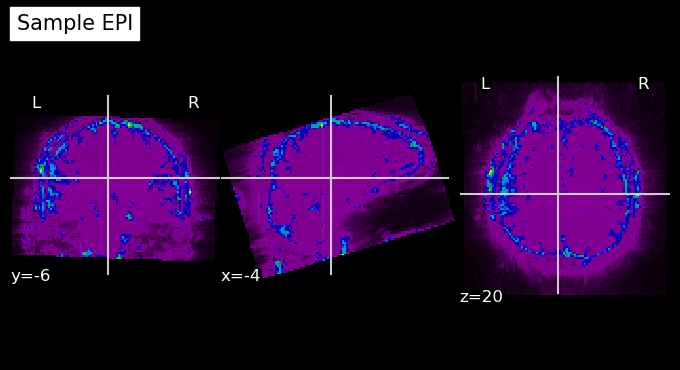

In [12]:
from nilearn import image
std_img = image.math_img("np.std(img, axis=-1)", img=subject_1)
plotting.plot_epi(std_img, title="Sample EPI")

[get_dataset_dir] Dataset found in C:\Users\benol\nilearn_data\fsl


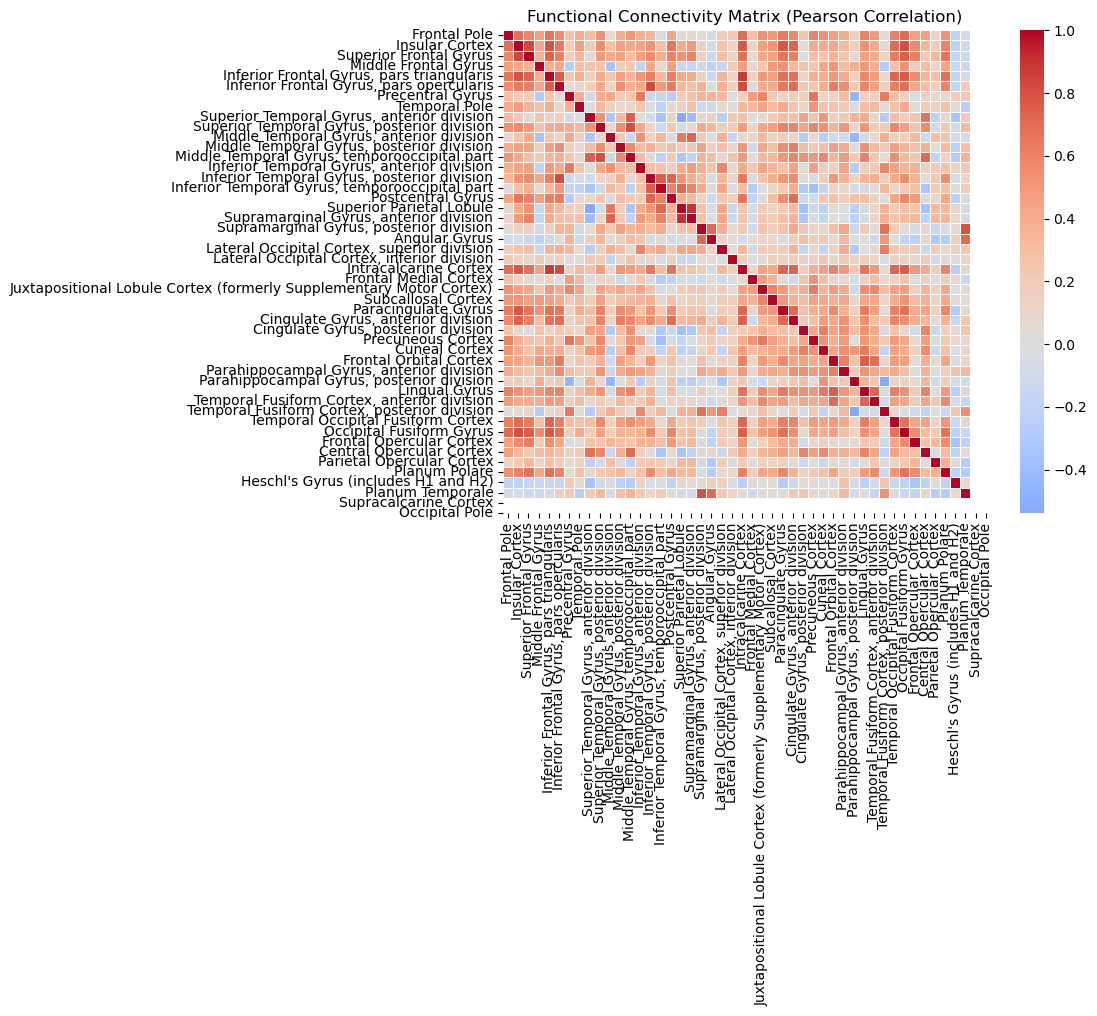

In [13]:
from nilearn.input_data import NiftiLabelsMasker
from nilearn import datasets, connectome
import seaborn as sns


atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr50-1mm')
masker = NiftiLabelsMasker(labels_img=atlas.maps, standardize=True)
timeseries = masker.fit_transform(subject_1)

correlation_measure = connectome.ConnectivityMeasure(kind='correlation')
correlation_matrix = connectome.ConnectivityMeasure(kind='correlation').fit_transform([timeseries])[0]

corr = np.array(correlation_matrix)

# Remove 'Background' label if present (index 0 in atlas.labels)
region_labels = atlas.labels[1:]
corr = corr[1:, 1:]

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, xticklabels=region_labels, yticklabels=region_labels,
            cmap='coolwarm', center=0, square=True, linewidths=0.5)

plt.title("Functional Connectivity Matrix (Pearson Correlation)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

C:\Users\benol\AppData\Local\Temp\ipykernel_23488\3202696850.py:5: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  resampled_atlas = resample_to_img(atlas.maps, mean_img)
c:\Users\benol\miniconda3\envs\mne\Lib\site-packages\nilearn\image\resampling.py:805: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(


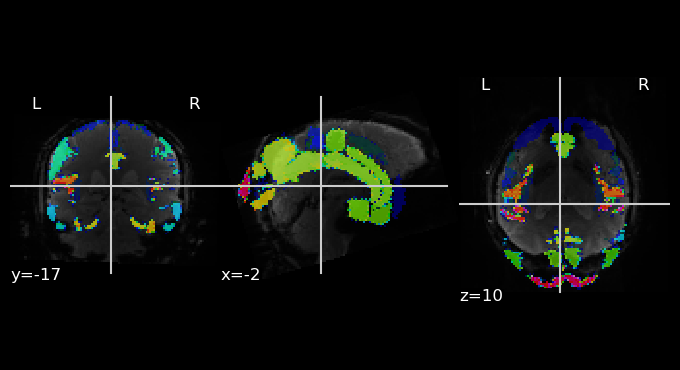

In [14]:
from nilearn.image import resample_to_img
from nilearn.plotting import plot_roi

#Atlas-Based Segmentation
resampled_atlas = resample_to_img(atlas.maps, mean_img)
plot_roi(resampled_atlas, bg_img=mean_img)

[Parcellations.fit] Loading data from [E:\neuro_data\ds004796\sub-01\func\sub-01_task-rest_dir-PA_bold.nii.gz]
[Parcellations.fit] Computing the mask
[Parcellations.fit] Resampling mask
[Parcellations.fit] Finished fit
[Parcellations.fit] Loading data
[Parcellations.fit] Loading data from Nifti1Image('E:\neuro_data\ds004796\sub-01\func\sub-01_task-rest_dir-PA_bold.nii.gz')
[Parcellations.fit] Smoothing images
[Parcellations.fit] Extracting region signals
[Parcellations.fit] Cleaning extracted signals
[Parcellations.fit] computing kmeans


C:\Users\benol\AppData\Local\Temp\ipykernel_23488\2938797676.py:5: FutureWarning: The nifti_maps_masker_ attribute is deprecated andwill be removed in Nilearn 0.11.3. Please use maps_masker_ instead.
  parcellator.fit(subject_1)


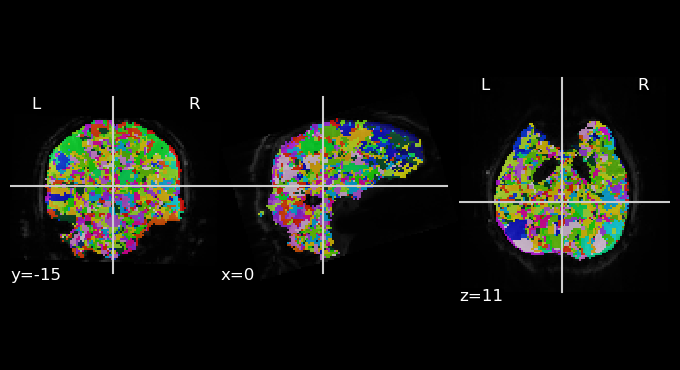

In [15]:
from nilearn.regions import Parcellations

# Unsupervised Segmentation (e.g., Clustering Voxels)
parcellator = Parcellations(n_parcels=50, method='kmeans', standardize=True)
parcellator.fit(subject_1)
plot_roi(parcellator.labels_img_, bg_img=mean_img)

In [ ]:
import json
#Visualize Feature Differences Between low risk and highrisk populations

# Extract Per-Subject Feature Vectors
atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr50-1mm')
labels_img = atlas.maps
masker = NiftiLabelsMasker(labels_img=labels_img, standardize=True)

def extract_features(fmri_path):
    timeseries = masker.fit_transform(fmri_path)  # (timepoints, n_regions)
    # Option 1: Flatten full correlation matrix
    corr = connectome.ConnectivityMeasure(kind='correlation').fit_transform([timeseries])[0]
    upper_tri = corr[np.triu_indices_from(corr, k=1)]  # Flatten upper triangle
    return upper_tri

def get_sub_files(sub_filepath, labels_filepath, data_dir):
    with open(sub_filepath, 'r') as f:
        fmri_subjects = json.load(f)

    with open(labels_filepath, 'r') as f:
        risk_labels = json.load(f)

    low_risk_subs = [sub for sub in fmri_subjects if risk_labels[sub] == 0]
    high_risk_subs = [sub for sub in fmri_subjects if risk_labels[sub] == 1]

    low_files = [os.path.join(data_dir, sub, 'func',f'{sub}_task-rest_dir-PA_bold.nii.gz') for sub in low_risk_subs]
    high_files = [os.path.join(data_dir, sub, 'func',f'{sub}_task-rest_dir-PA_bold.nii.gz') for sub in high_risk_subs]

    return low_files, high_files

fmri_subjects = r"..\data\available_fmri_subjects.json"
risk_labels = r"..\data\sub_risk_labels.json"

low_files, high_files = get_sub_files(fmri_subjects, risk_labels, data_dir)

X = [extract_features(p) for p in low_files + high_files]
y = [0] * len(low_files) + [1] * len(high_files)  # 0 = Group 1, 1 = Group 2

X = np.array(X)
y = np.array(y)

[get_dataset_dir] Dataset found in C:\Users\benol\nilearn_data\fsl


c:\Users\benol\miniconda3\envs\mne\Lib\site-packages\nilearn\maskers\nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.uint8(37), np.uint8(14)}. Label image only contains 46 labels (including background).
  warnings.warn(
c:\Users\benol\miniconda3\envs\mne\Lib\site-packages\nilearn\maskers\nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.uint8(25)}. Label image only contains 45 labels (including background).
  warnings.warn(
c:\Users\benol\miniconda3\envs\mne\Lib\site-packages\nilearn\maskers\nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.uint8(37)}. Label image only contains 47 labels (including background).
  warnings.warn(
c:\Users\benol\miniconda3\envs\mne\Lib\site-packages\nilearn\maskers\nifti_labels_masker.py:888: UserWarning: After 

In [ ]:
import umap
import matplotlib.pyplot as plt

X_umap = umap.UMAP(n_neighbors=10, min_dist=0.1, metric='correlation', random_state=42).fit_transform(X)

# Plot
plt.figure(figsize=(8, 6))
colors = ['royalblue', 'tomato']
labels = ['Group 1', 'Group 2']

for label, color in zip([0, 1], colors):
    idx = y == label
    plt.scatter(X_umap[idx, 0], X_umap[idx, 1], label=labels[label], alpha=0.7, color=color)

plt.title("t-SNE Projection of fMRI Functional Connectivity")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
avg_conn_group1 = np.mean([connectome.ConnectivityMeasure().fit_transform([masker.fit_transform(p)])[0] for p in low_files], axis=0)
avg_conn_group2 = np.mean([connectome.ConnectivityMeasure().fit_transform([masker.fit_transform(p)])[0] for p in high_files], axis=0)
diff_matrix = avg_conn_group2 - avg_conn_group1

def plot_connectivity_matrix(matrix, title, labels, vmin=-1, vmax=1, center=0):
    plt.figure(figsize=(12, 10))
    sns.heatmap(matrix, xticklabels=labels, yticklabels=labels,
                cmap="coolwarm", vmin=vmin, vmax=vmax, center=center,
                square=True, linewidths=0.5)
    plt.title(title)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_connectivity_matrix(avg_conn_group1[1:, 1:], "Average Connectivity: Group 1", region_labels)
plot_connectivity_matrix(avg_conn_group2[1:, 1:], "Average Connectivity: Group 2", region_labels)
plot_connectivity_matrix(diff_matrix[1:, 1:], "Connectivity Difference (Group 2 - Group 1)", region_labels, vmin=-0.5, vmax=0.5)

In [ ]:
from scipy.stats import ttest_ind

# Convert to array
group1 = X[y == 0]
group2 = X[y == 1]

t_stats, p_vals = ttest_ind(group1, group2)